# 　超参的最优化
神经网络中，除了权重和偏置等参数，超参数（hyper-parameter）也经
常出现。这里所说的超参数是指，比如各层的神经元数量、batch大小、参
数更新时的学习率或权值衰减等。如果这些超参数没有设置合适的值，模型
的性能就会很差。虽然超参数的取值非常重要，但是在决定超参数的过程中
一般会伴随很多的试错

In [ ]:

import sys, os
sys.path.append(os.pardir)
import numpy as np
from typing import Dict, List
import matplotlib.pyplot as plt

from libs.network import NeuralNet
from libs.trainer import Trainer
from libs.util import smooth_curve, shuffle_dataset_and_split_validation_dataset

# 设置字体为华文细黑
plt.rcParams['font.sans-serif'] = ['STHeiti']  # macOS 上的华文细黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

### 验证数据
> 之前我们使用的数据集分成了训练数据和测试数据，训练数据用于学习，
测试数据用于评估泛化能力。由此，就可以评估是否只过度拟合了训练数据
（是否发生了过拟合），以及泛化能力如何等。

> 下面我们要对超参数设置各种各样的值以进行验证。这里要注意的是，
不能使用测试数据评估超参数的性能。这一点非常重要，但也容易被忽视


> 为什么不能用测试数据评估超参数的性能呢？这是因为如果使用测试数
据调整超参数，超参数的值会对测试数据发生过拟合。换句话说，用测试数
据确认超参数的值的“好坏”，就会导致超参数的值被调整为只拟合测试数据。
这样的话，可能就会得到不能拟合其他数据、泛化能力低的模型。

> 因此，调整超参数时，必须使用超参数专用的确认数据。用于调整超参
数的数据，一般称为验证数据（validation data）。我们使用这个验证数据来
评估超参数的好坏

In [2]:
# 加载数据集
from dataset.mnist import load_mnist

(x_train, t_train), (x_test, t_test) = load_mnist(normalize=True, flatten=True, one_hot_label=True)

# 为了实现高速化，减少训练数据
x_train = x_train[:500]
t_train = t_train[:500]

# 分割验证数据
x_train, x_val, t_train, t_val = shuffle_dataset_and_split_validation_dataset(x_train, t_train, val_ratio=0.2)

print(f"x_train: {x_train.shape}")
print(f"t_train: {t_train.shape}")
print(f"x_val: {x_val.shape}")
print(f"t_val: {t_val.shape}")

# 注意: 优化超参过程不使用测试集!!!

save_file: /Users/simeon/WorkSpace/Projects/Practice/DeepLearnStudy/example/../dataset/data/mnist.pkl
x_train: (400, 784)
t_train: (400, 10)
x_val: (100, 784)
t_val: (100, 10)


In [3]:
def start_train(optimizer: str='sgd', optimizer_param: Dict={}, hidden_size_list: List[int]=[100, 100, 100, 100, 100, 100], 
                epochs: int=50, mini_batch_size: int=100, activation: str="relu", weight_scale: str|float="he", 
                weight_decay_lambda: float=0.0, use_dropout: bool=False, dropout_ration: float=0.5, use_batchnorm=False
    ) -> List[float]:
    trainer = Trainer(
        network=NeuralNet(input_size=x_train.shape[1], hidden_size_list=hidden_size_list, 
                              output_size=t_train.shape[1], activation=activation, weight_scale=weight_scale, 
                              weight_decay_lambda=weight_decay_lambda, 
                              use_dropout=use_dropout, dropout_ration=dropout_ration, use_batchnorm=use_batchnorm),
        x_train=x_train,
        t_train=t_train,
        x_test=x_test,
        t_test=t_test,
        optimizer=optimizer,
        optimizer_param=optimizer_param,
        epochs=epochs,
        mini_batch_size=mini_batch_size,
        verbose=True
    )
    trainer.train()
    return trainer.train_loss_list, trainer.train_acc_list, trainer.test_acc_list

In [4]:

epochs = 50
optimization_trail = 100
result_list = []
for i in range(optimization_trail):
    print(f"第 {i + 1} 次超参优化尝试")
    
    # 设置需要优化的超参数范围
    lr = 10 ** np.random.uniform(-6, -2)  # 学习率
    weight_decay_lambda = 10 ** np.random.uniform(-8, -4)  # 权重衰减系数
    _, train_acc_list, val_acc_list = start_train(epochs=epochs, optimizer='sgd', optimizer_param={'lr': lr}, weight_decay_lambda=weight_decay_lambda,)
    print(f"学习率: {lr}, 权重衰减系数: {weight_decay_lambda}, 训练集准确率: {train_acc_list[-1]}, 验证集准确率: {val_acc_list[-1]}")
    result_list.append({
        'lr': lr,
        'weight_decay_lambda': weight_decay_lambda,
        'train_acc_list': train_acc_list,
        'val_acc_list': val_acc_list,
    })

第 1 次超参优化尝试
网络结构:
	【全连接层】: Affine1, W1(784:100), b1(100)
	【激活层】: Relu1
	【全连接层】: Affine2, W2(100:100), b2(100)
	【激活层】: Relu2
	【全连接层】: Affine3, W3(100:100), b3(100)
	【激活层】: Relu3
	【全连接层】: Affine4, W4(100:100), b4(100)
	【激活层】: Relu4
	【全连接层】: Affine5, W5(100:100), b5(100)
	【激活层】: Relu5
	【全连接层】: Affine6, W6(100:100), b6(100)
	【激活层】: Relu6
	【全连接层】: Affine7, W7(100:10), b7(10)
	【Softmax + Loss】
开始训练...
epoch:1, loss:288.92239701384926, train acc:0.0975, test acc:0.1025
epoch:2, loss:302.13919865461907, train acc:0.0975, test acc:0.1025
epoch:3, loss:321.96398728936833, train acc:0.0975, test acc:0.1025
epoch:4, loss:300.0987506486994, train acc:0.0975, test acc:0.1025
epoch:5, loss:325.3136740941539, train acc:0.0975, test acc:0.1025
epoch:6, loss:311.0476579076576, train acc:0.0975, test acc:0.1025
epoch:7, loss:276.1286868105639, train acc:0.0975, test acc:0.1025
epoch:8, loss:276.7705068757855, train acc:0.0975, test acc:0.1025
epoch:9, loss:313.2529225944958, train acc:0.0975, test acc:0.

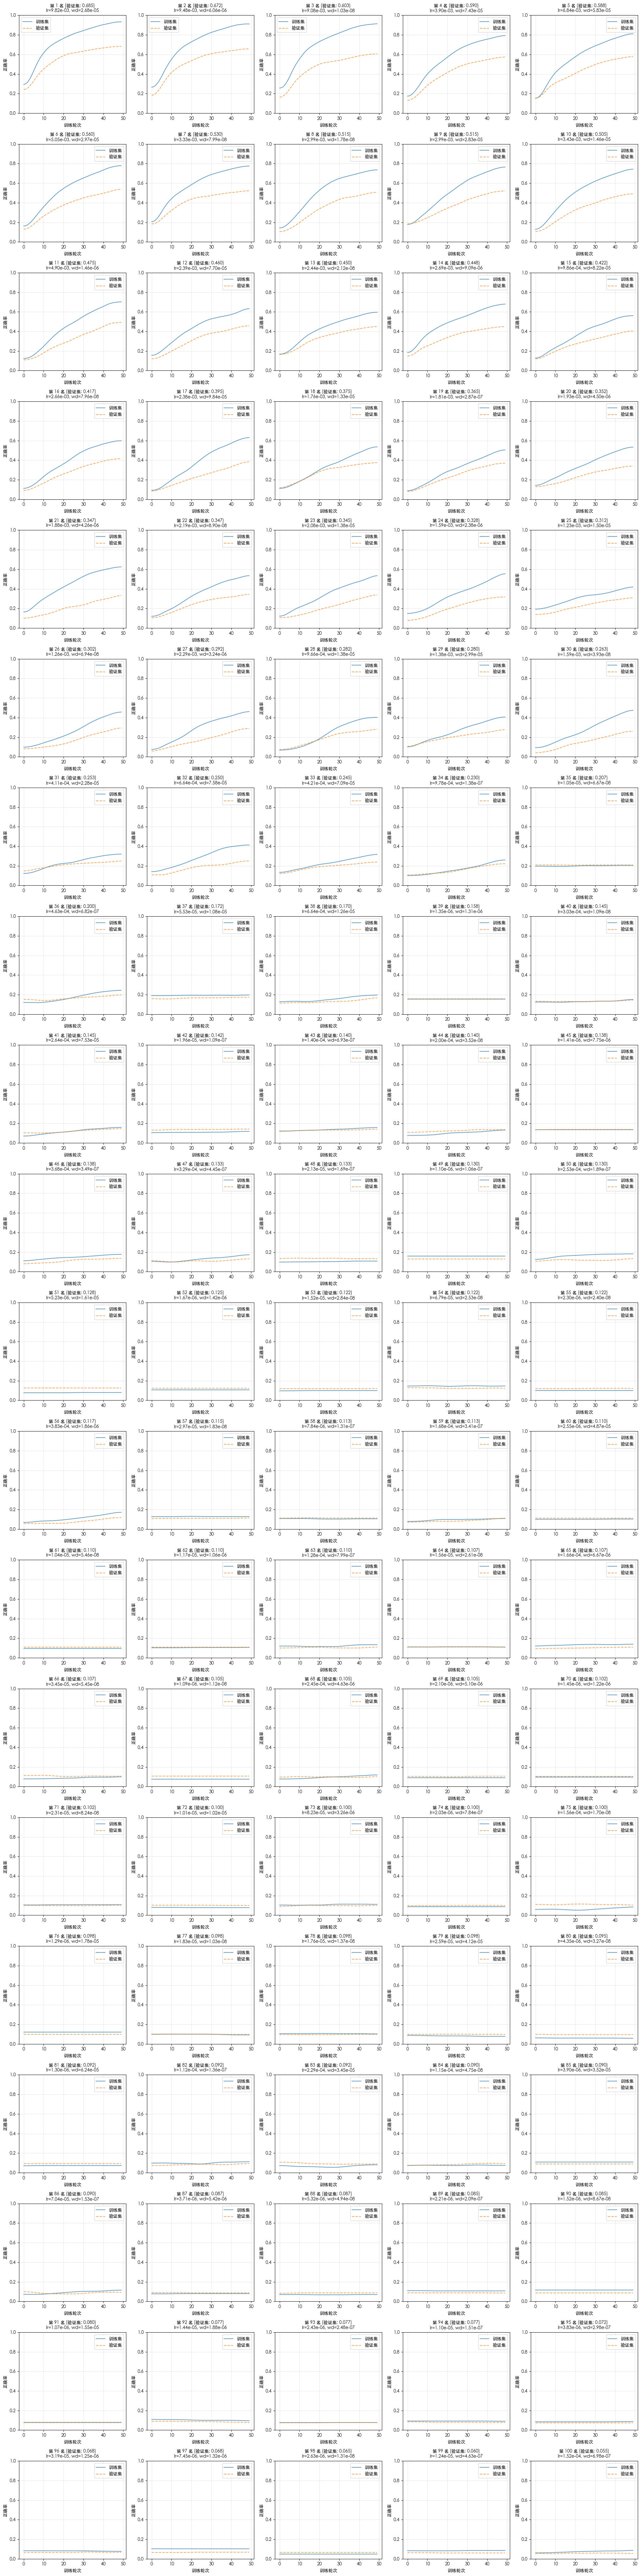

In [11]:
# 按照验证集准确率排序（从高到低）
sorted_results = sorted(result_list, key=lambda x: x['val_acc_list'][-1], reverse=True)

# 计算子图的行列数
n_results = len(sorted_results)
cols = 5  # 每行显示5个图
rows = (n_results + cols - 1) // cols  # 计算需要的行数

# 创建子图
fig, axes = plt.subplots(rows, cols, figsize=(20, 4*rows))
axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes

for i, result in enumerate(sorted_results):
    ax = axes[i]
    ax.plot(smooth_curve(result['train_acc_list']), label='训练集', alpha=0.7)
    ax.plot(smooth_curve(result['val_acc_list']), label='验证集', linestyle='--', alpha=0.7)
    
    # 在标题中显示排名和最终验证集准确率
    final_val_acc = result['val_acc_list'][-1]
    ax.set_title(f'第 {i+1} 名 (验证集: {final_val_acc:.3f})\nlr={result["lr"]:.2e}, wd={result["weight_decay_lambda"]:.2e}', fontsize=10)
    ax.set_xlabel('训练轮次')
    ax.set_ylabel('正确率')
    ax.legend()
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)

# 隐藏多余的子图
for i in range(n_results, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

最佳超参数: 学习率=9.82e-03, 权重衰减系数=2.68e-05, 最终验证集准确率=0.6850


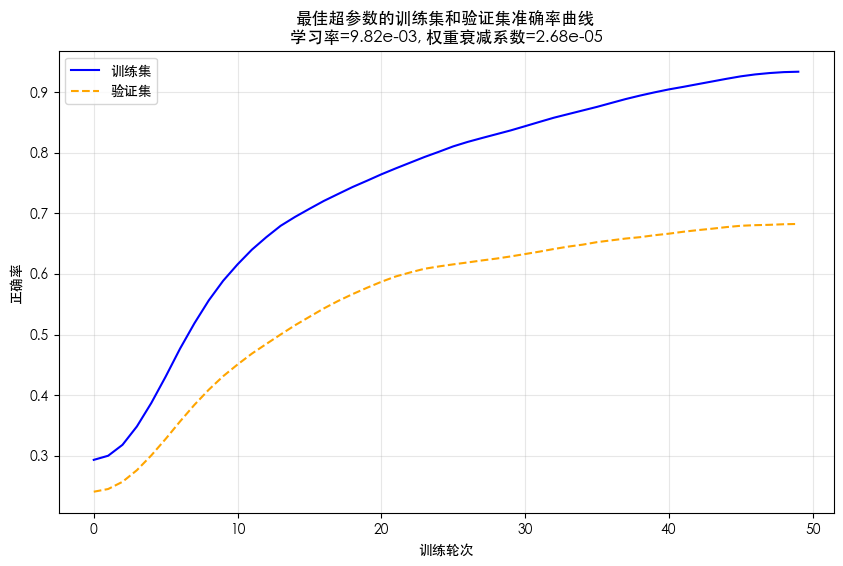

In [12]:
# 选择最佳超参数
best_result = max(result_list, key=lambda x: x['val_acc_list'][-1])
print(f"最佳超参数: 学习率={best_result['lr']:.2e}, 权重衰减系数={best_result['weight_decay_lambda']:.2e}, 最终验证集准确率={best_result['val_acc_list'][-1]:.4f}")
# 绘制最佳超参数的训练集和验证集准确率曲线
plt.figure(figsize=(10, 6))
plt.plot(smooth_curve(best_result['train_acc_list']), label='训练集', color='blue')
plt.plot(smooth_curve(best_result['val_acc_list']), label='验证集', color='orange', linestyle='--')
plt.title(f'最佳超参数的训练集和验证集准确率曲线\n学习率={best_result["lr"]:.2e}, 权重衰减系数={best_result["weight_decay_lambda"]:.2e}')
plt.xlabel('训练轮次')
plt.ylabel('正确率')
plt.legend()
plt.grid(True, alpha=0.3)
ax.set_ylim(0, 1)
plt.show()